In [104]:
import pandas as pd
import matplotlib.pyplot as plt


In [105]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from lisatools.utils.constants import *
from copy import deepcopy  # can be useful
import h5py
import astropy

In [106]:

import matplotlib
from matplotlib.image import NonUniformImage
from scipy.stats import gmean
# imports 
from bbhx.waveforms.phenomhm import PhenomHMAmpPhase
from lisatools.sensitivity import get_sensitivity
from bbhx.waveformbuild import BBHWaveformFD
from eryn.prior import uniform_dist
from itertools import chain, repeat
import random
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
from astropy.cosmology import z_at_value, Planck18, Planck13

# imports
from lisatools.sensitivity import AET1SensitivityMatrix
from lisatools.datacontainer import DataResidualArray
from lisatools.analysiscontainer import AnalysisContainer
import math
import pickle

# BH Data

In [107]:
df = pd.read_csv("jillian.txt", sep="\t", dtype={"time (Gyr)": float, "mass ratio": float, "redshift": float, "total BH mass (Msun)": float})

In [108]:
time= df['time (Gyr)']
ratio= df['mass ratio']
z=np.array(df['redshift'])
M=df['total BH mass (Msun)']

In [109]:
m1=np.array(M/(1+ratio))

In [110]:
m2=np.array(ratio*m1)

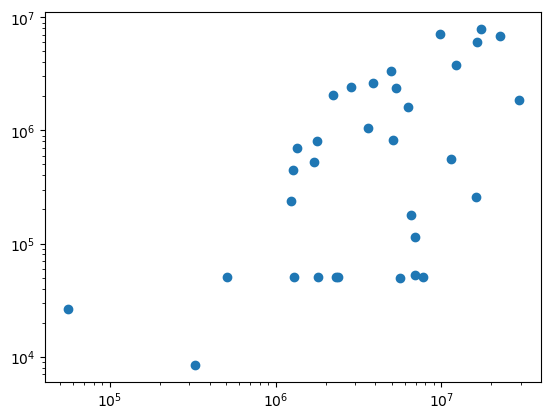

In [111]:
plt.loglog(m1,m2,'o')

In [112]:
cosmo = FlatLambdaCDM(H0=67.74, Om0=0.3089, Tcmb0=2.725)
d_l=np.array(cosmo.luminosity_distance(z).value*1e6*PC_SI)

# Functions

In [113]:
arr_size = len(m1)
tdi_wave_gen = BBHWaveformFD()

def wrap(*args, **kwargs):
    return tdi_wave_gen(*args, **kwargs)[0]

def SNR_calc_stoch(m1 = m1, m2 = m2, dist = d_l, chi1 = np.full(arr_size, 0.5),
             chi2 = np.full(arr_size, 0.7), phi_ref = np.full(arr_size, 0.6),
             f_ref = np.full(arr_size, 0.0), inc = np.full(arr_size, np.pi / 8),
             lam = np.full(arr_size, 0.5), beta = np.full(arr_size, -0.7),
             psi = np.full(arr_size, np.pi / 4), t_ref = np.full(arr_size, 0.5 * YRSID_SI),
             num_elements = len(m1),obs=1,z=z,t_obs_end=1):
    length = 1024

    # Setup data holders
    Tobs = YRSID_SI / 12*obs    # 1 month
    dt = 10.0  # sec
    N = int(Tobs / dt)
    Tobs = N * dt

    freqs = np.fft.rfftfreq(N, dt)
    freqs=freqs[freqs>=10**(-4)]
    
    SNR_new = []

    for i in range(num_elements):
        AET_gen = tdi_wave_gen(
            m1[i],
            m2[i], 
            chi1[i],
            chi2[i],
            dist[i], 
            phi_ref[i],
            f_ref[i], 
            inc[i],
            lam[i],
            beta[i],
            psi[i],
            t_ref[i],
            t_obs_start=0,
            t_obs_end=t_obs_end,         
            length=1024, 
            combine=False,  # TODO: check this
            direct=False,
            fill=True,
            squeeze=True,
            freqs=freqs
        )
     
        data = DataResidualArray(AET_gen[0], f_arr=freqs)
        sens_mat = AET1SensitivityMatrix(data.f_arr,stochastic_params=(4.0 * YRSID_SI,))
        analysis = AnalysisContainer(data, sens_mat, signal_gen=wrap)
        snr = analysis.snr()
        SNR_new.append(snr)

    return SNR_new

In [114]:
def draw_params(m1 = m1, 
                m2 = m2, dist = d_l,z=z,n=1): 
                
    arr_size=len(m1)*n
    
    znew = np.array(list(chain.from_iterable(repeat(x, n) for x in z)))
    m1new = np.array(list(chain.from_iterable(repeat(x, n) for x in m1)))*(znew+1)
    m2new = np.array(list(chain.from_iterable(repeat(x, n) for x in m2)))*(znew+1)
    distnew = np.array(list(chain.from_iterable(repeat(x, n) for x in dist)))
        

    # chi1 = np.full(arr_size, spin)
    # chi2 = np.full(arr_size, spin)
    
    phi_ref =  uniform_dist(0.0, 2 * np.pi).rvs(arr_size)
    f_ref = np.full(arr_size, 0)
    inc = np.arccos(uniform_dist(-1.0, 1.0).rvs(arr_size))
    lam = uniform_dist(0.0, 2 * np.pi).rvs(arr_size)
    beta = np.arcsin(uniform_dist(-1.0, 1.0).rvs(arr_size))
    psi = uniform_dist(0.0, np.pi).rvs(arr_size)
    t_ref = np.full(arr_size, 1e6)

    result={
         'm1'  : m1new,
         'm2'  : m2new,
         'z'   : znew,
        'dist' : distnew,
        # 'chi1':chi1,
        # 'chi2':chi2,
        'phi_ref': phi_ref,
        'f_ref': f_ref,
        'inc' : inc,
        'lam' : lam,
        'beta': beta,
        'psi' : psi,
        't_ref': t_ref,
        'num_elements':arr_size
    }
     
    return result

In [115]:
def avg_hist(x,y,z, bins=(20,20), c1='YlOrRd', c2= 'YlGnBu',  labelx=None, labely=None,
            labelz=None, norm1=matplotlib.colors.LogNorm(), logweight=True, 
            norm2=None, vmin=None,vmax=None):
 #            norm2=matplotlib.colors.LogNorm(vmin=None, vmax=None) ):
    z_mask=((~np.isnan(z))&(~np.isnan(x))&(~np.isnan(y)))
    x=x[z_mask]
    y=y[z_mask]
    z=z[z_mask]
    H_num, xedges, yedges = np.histogram2d(x, y, bins=bins)
    if logweight:
        z=np.log10(z)
    H_z, xedges, yedges = np.histogram2d(x,y, bins=(xedges, yedges), weights=z)
    H_num=H_num.T
    H_z=H_z.T
    plt.figure(figsize=(15,10))
    plt.subplot(2, 1, 1)
    plt.imshow(H_num, interpolation='nearest', origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], 
           cmap= c1, norm=norm1)
 
    plt.xlabel(labelx)
    plt.ylabel(labely)
    plt.colorbar(label='Numbers')

    plt.subplot(2,1,2)
    plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], 
               cmap=c2, norm=norm2, vmax=vmax,vmin=vmin)
    #print(np.min(H_z/H_num), np.max(H_z/H_num))
    #print(H_z/H_num)
   
    plt.xlabel(labelx)
    plt.ylabel(labely)
    plt.colorbar(label=labelz)
   
    
    plt.tight_layout()
    plt.gca().set_aspect('equal')


# Analysis


In [116]:
pop_J=draw_params(n=1)

In [117]:
snr_j=SNR_calc_stoch(**pop_J,chi1 = np.full(arr_size, 0.8),chi2 = np.full(arr_size, 0.8))

Text(0, 0.5, 'log(SNR)')

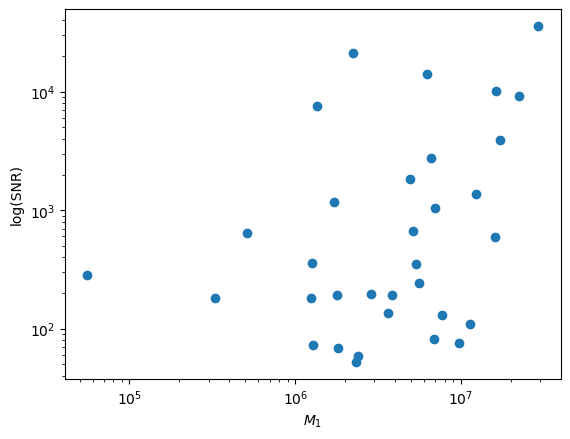

In [118]:
plt.loglog(m1,snr_j,'o')
plt.xlabel('$M_1$')
plt.ylabel('log(SNR)')

In [119]:
# from lisatools.sources import EMRICalculationController

In [120]:
# from lisatools.sources import BBHCalculationController

In [121]:
# controller = BBHCalculationController(psd='lisatools.sensitivity.A1TDISens') 
# snr_bbh = controller.get_snr()

/tmp/ipykernel_5581/4001164011.py:25: RuntimeWarning: invalid value encountered in divide
  plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],


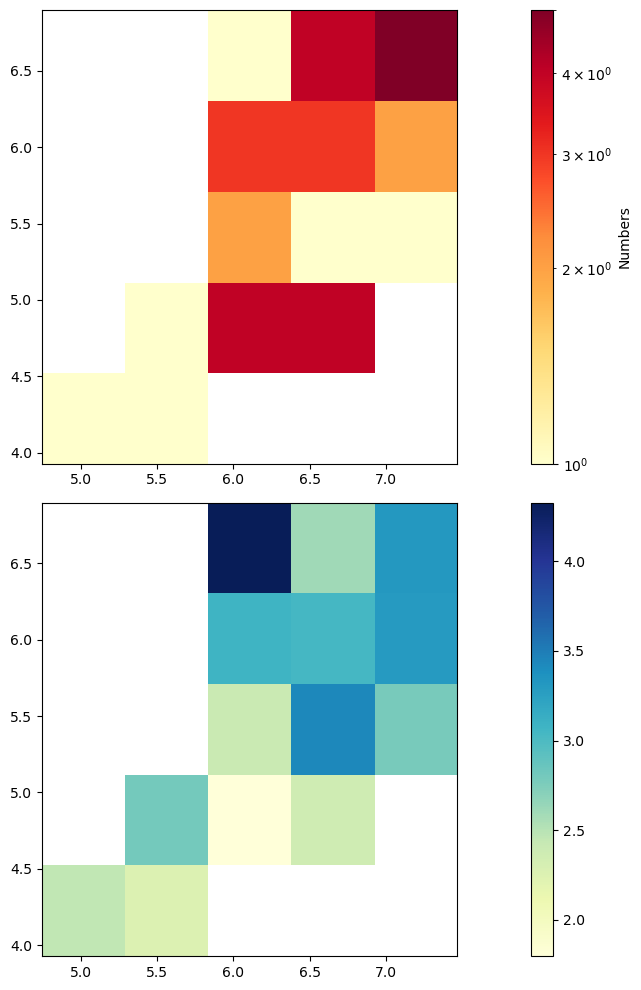

In [122]:
avg_hist(np.log10(m1),np.log10(m2),np.array(snr_j),bins=(5,5))

Text(0, 0.5, '$M_2$')

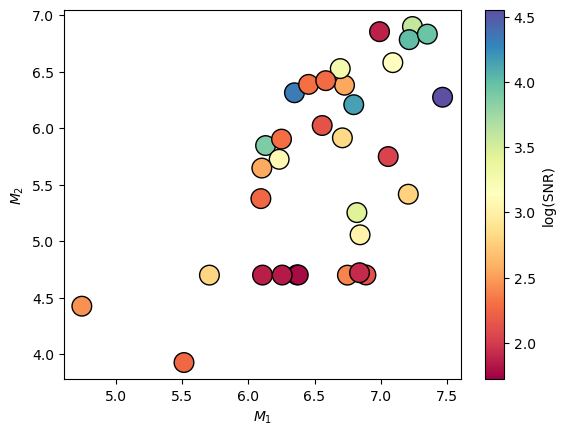

In [147]:
sc=plt.scatter(
    np.log10(m1),  # X-axis
    np.log10(m2),  # Y-axis
    c=np.log10(snr_j),  # Color by redshift
    cmap="Spectral",  # Choose a colormap (e.g., 'viridis', 'plasma', 'coolwarm')
    edgecolors="k", 
    alpha=1,s=200
)
cbar=plt.colorbar(sc)
cbar.set_label("log(SNR)")
plt.xlabel('$M_1$')
plt.ylabel('$M_2$')
